# Emotions classification from Images

- Now you can download the fer2013_2_classes.zip file which is in the Datasets folder in the Google Drive. This new dataset is composed of only angry and happy images, so you can build a classifier in order to detect only those emotions and compare the results

- Try to play with the parameters and also with the neural network structure to see how the results change. You can also try to use the original fer2013 dataset and build a classifier for all the emotions.

### Import libraries and modules

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import zipfile
import tensorflow as tf

from google.colab.patches import cv2_imshow
from google.colab import drive

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization

from keras.models import save_model

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

### Loading the images

In [2]:
drive.mount('/content/drive')
# Define paths for images, classifiers and models
image_folder_path = '/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/'

Mounted at /content/drive


In [3]:
path = image_folder_path +'/Datasets/fer2013_2_classes.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

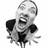

In [4]:
tf.keras.preprocessing.image.load_img('/content/fer2013_2_classes/train/Angry/1003.jpg')

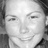

In [5]:
image = tf.keras.preprocessing.image.load_img('/content/fer2013_2_classes/train/Happy/1.jpg')
image

### Train and Test dataset

In [6]:
# Create an instance of the ImageDataGenerator class for data augmentation, which will generate batches of tensor image data with real-time data augmentation. 
# The data will be looped over (in batches) indefinitely. The ImageDataGenerator class allows you to configure random transformations and normalization operations to be done on your image data during training. This is useful for training deep learning models as it helps to prevent overfitting and improve generalization. 
# Also, it can be used to rescale pixel values, apply random transformations like rotation, flipping, shifting, and zooming to the images in the training dataset. This helps to create a more diverse set of training examples and improve the model's ability to generalize to new data. 
training_generator = ImageDataGenerator(
    rescale=1./255,         # Rescale the pixel values 
    rotation_range=7,       # Randomly rotate images in the range (degrees, 0 to 180)
    horizontal_flip=True,   # Randomly flip inputs horizontally
    vertical_flip=True,    # Randomly flip inputs vertically
    width_shift_range=0.2,  # Randomly translate images horizontally (fraction of total width)
    zoom_range=0.2          # Randomly zoom images
)

# Train dataset is created using the flow_from_directory method of the ImageDataGenerator class. This method takes the path to the directory containing the training images, along with other parameters such as target size, batch size, class mode, and shuffle. 
# The target size specifies the dimensions to which all images will be resized, while the batch size determines how many images will be processed in each batch. The class mode specifies how the labels are generated (in this case, categorical), and shuffle indicates whether to shuffle the data after each epoch.
train_dataset = training_generator.flow_from_directory(
    '/content/fer2013_2_classes/train',   # Path to the directory containing the training images
    target_size = (48, 48),     # Resize all images to 48x48 pixels
    batch_size = 16,            # Number of images to be yielded from the generator per batch
    class_mode = 'categorical', # Specify the type of label arrays that are returned: 'categorical' means 2D one-hot encoded labels
    shuffle = True,             # Whether to shuffle the data after each epoch
)

Found 11210 images belonging to 2 classes.


In [7]:
train_dataset.classes

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [8]:
# Get the unique classes and their counts in the training dataset using numpy's unique function. This will return an array of unique class labels and an array of their corresponding counts.
np.unique(train_dataset.classes, return_counts=True)

(array([0, 1], dtype=int32), array([3995, 7215]))

In [9]:
# Get the class indices mapping from the training dataset. This will return a dictionary where the keys are the class labels and the values are the corresponding integer indices assigned to each class.
train_dataset.class_indices

{'Angry': 0, 'Happy': 1}

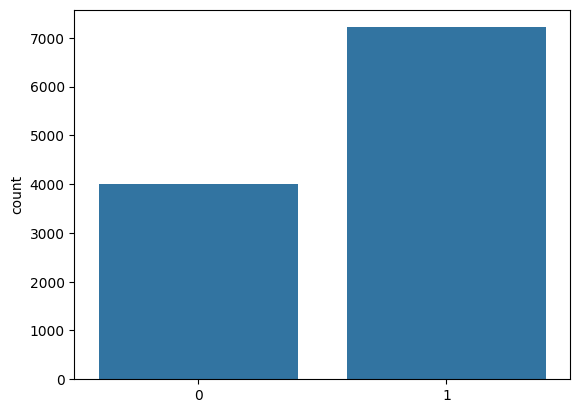

In [10]:
sns.countplot(x = train_dataset.classes);

In [11]:
test_generator = ImageDataGenerator(rescale=1./255)

test_dataset = test_generator.flow_from_directory(
    '/content/fer2013_2_classes/validation', 
    target_size = (48, 48), 
    batch_size = 1, 
    class_mode = 'categorical', 
    shuffle = False
)

Found 1370 images belonging to 2 classes.


### Building and training the convolutional neural network

In [12]:
num_detectors = 32
num_classes = 2
width, height = 48, 48
epochs = 50

network = Sequential()

network.add(Conv2D(num_detectors, (3, 3), activation = 'relu', padding = 'same', input_shape = (width, height, 3)))
network.add(BatchNormalization())
network.add(Conv2D(num_detectors, (3, 3), activation = 'relu', padding = "same"))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2, 2)))
network.add(Dropout(0.2))

network.add(Conv2D(2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(Conv2D(2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2, 2)))
network.add(Dropout(0.2))

network.add(Conv2D(2*2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(Conv2D(2*2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2, 2)))
network.add(Dropout(0.2))

network.add(Conv2D(2*2*2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(Conv2D(2*2*2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2, 2)))
network.add(Dropout(0.2))

network.add(Flatten())
network.add(Dense(2*num_detectors, activation = 'relu'))
network.add(BatchNormalization())
network.add(Dropout(0.2))

network.add(Dense(2*num_detectors, activation = 'relu'))
network.add(BatchNormalization())
network.add(Dropout(0.2))

network.add(Dense(num_classes, activation='softmax'))

print(network.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,328,418 (5.07 MB)

 Trainable params: 1,326,242 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

None


In [13]:
network.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [14]:
network.fit(train_dataset, epochs=epochs)

Epoch 1/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step - accuracy: 0.5929 - loss: 0.7434
Epoch 2/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.6254 - loss: 0.6529
Epoch 3/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.6511 - loss: 0.6298
Epoch 4/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.6860 - loss: 0.5925
Epoch 5/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7234 - loss: 0.5497
Epoch 6/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7613 - loss: 0.4892
Epoch 7/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7847 - loss: 0.4506
Epoch 8/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.8008 - loss: 0.4316
Epoch 9/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.8128 - loss: 0.4089
Epoch 10/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.8301 - loss: 0.3833
Epoch 11/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.8299 - loss: 0.3812
Epoch 12/50
701/701 ━━━━━━━━━━

### Evaluate neural network

In [15]:
# Evaluate the loaded model on the test dataset to assess its performance. The evaluate method computes the loss and accuracy metrics for the model on the provided test dataset, allowing you to see how well the model generalizes to unseen data. 
network.evaluate(test_dataset)

1370/1370 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9263 - loss: 0.6708


[0.6707987189292908, 0.9262773990631104]

In [16]:
# Generate predictions for the test dataset using the loaded model. The predict method takes the test dataset as input and returns the predicted probabilities for each class for each image in the test dataset. These predictions can then be used to evaluate the model's performance or to make decisions based on the predicted classes.
predictions = network.predict(test_dataset)
predictions

1370/1370 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


array([[0.99334913, 0.00665087],
       [0.99750406, 0.00249601],
       [0.98324585, 0.01675412],
       ...,
       [0.00344055, 0.99655944],
       [0.00348612, 0.99651384],
       [0.00185611, 0.9981439 ]], dtype=float32)

In [17]:
# Convert the predicted probabilities into class labels by taking the index of the maximum value along the second axis (axis=1) for each prediction. This will give you the predicted class label for each image in the test dataset, which can then be compared to the true labels to evaluate the model's performance.
predictions = np.argmax(predictions, axis = 1)
predictions

array([0, 0, 0, ..., 1, 1, 1])

In [18]:
test_dataset.classes

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [19]:
accuracy_score(test_dataset.classes, predictions)

0.9262773722627737

In [20]:
test_dataset.class_indices

{'Angry': 0, 'Happy': 1}

In [21]:
cm = confusion_matrix(test_dataset.classes, predictions)
cm

array([[454,  37],
       [ 64, 815]])

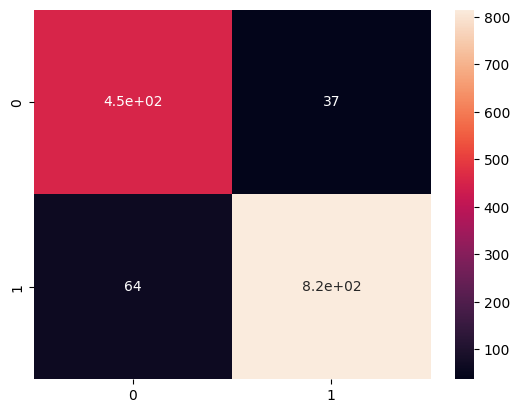

In [22]:
sns.heatmap(cm, annot=True);

In [23]:
# Generate a classification report for the test dataset using the true labels and predicted labels. The classification report provides a summary of the precision, recall, F1-score, and support for each class in the dataset. This information can be used to evaluate the performance of the model on each emotion class and identify any areas where the model may need improvement.
print(classification_report(test_dataset.classes, predictions))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       491
           1       0.96      0.93      0.94       879

    accuracy                           0.93      1370
   macro avg       0.92      0.93      0.92      1370
weighted avg       0.93      0.93      0.93      1370

